# Generating visibilities from custom true sky image

This notebook aim to generate **visibilities** $V(u,v,w)$ from custom **true sky image** $I(l,m)$ with the standard **dataflow degridding** method.

- The **true sky image** is a `GRID_SIZE`x`GRID_SIZE` grid projected in the celestial plan $(l,m)$ a.k.a spatial domain.
- The **visibilities** $V(u,v,w)$ are measured in the $u,v$ space a.k.a the Fourier (spectral) domain.

The process of transforming a **gridded sky image** into **visibilities** is called **degridding**. It consists of interpolating the sampled uv-coordinates from the discretized Fourier transform of the image. This is the inverse operation of gridding, which maps measured visibilities onto a uniform grid before applying an FFT to reconstruct an image.

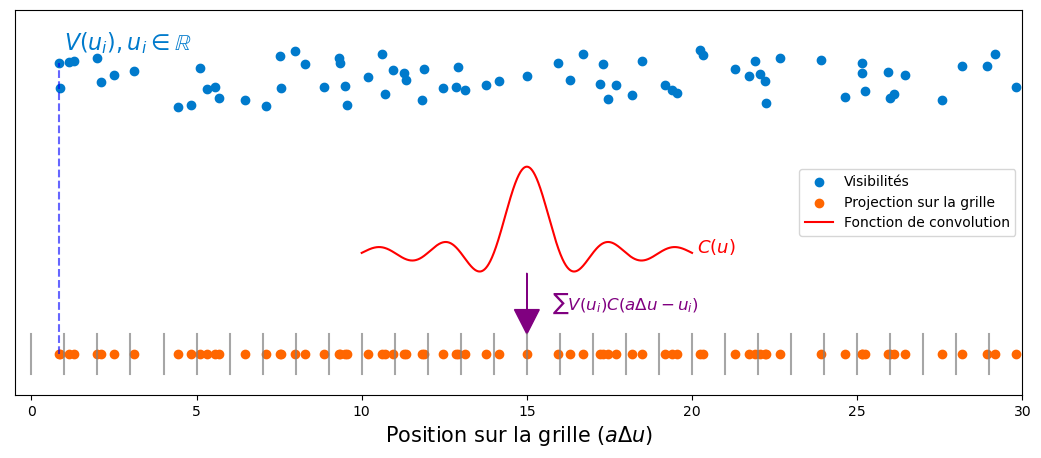

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def kaiser_bessel_kernel(x, alpha=0.5, a=5):
    return np.sinc(x) * np.i0(alpha * np.sqrt(1 - (x/a)**2))

# Paramètres de la grille et des visibilités
N = 30  # Nombre de points sur la grille
dx = 1  # Pas de la grille
a = np.arange(N)  # Indices de la grille
M = 75  # Nombre de visibilités

# Position du point de convolution
center_pos = (N // 2) * dx
conv_half_width = 5 * dx
conv_x = np.linspace(-conv_half_width, conv_half_width, 1000)

# Génération des visibilités aléatoires
vis_x = np.sort(np.random.rand(M) * N * dx)
vis_values = 1.5 + np.random.rand(M) * 0.7 + 0.3

# Création de la figure
plt.figure(figsize=(13, 5))
ax = plt.axes()
ax.axes.get_yaxis().set_visible(False)

# Affichage de la grille
for x in a * dx:
    plt.plot([x, x], [-1.5, -1.0], color='gray', linestyle='-', alpha=0.7)

# Affichage des visibilités
plt.scatter(vis_x, vis_values, color='#007acc', label='Visibilités')
plt.scatter(vis_x, np.ones(M) * -1.25, color='#ff6600', label='Projection sur la grille')
plt.plot([vis_x[0], vis_x[0]], [-1.25, vis_values[0]], 'b--', alpha=0.6)

# Affichage du kernel de convolution (Kaiser-Bessel)
plt.plot(center_pos + conv_x, kaiser_bessel_kernel(conv_x), color='red', label='Fonction de convolution')

# Texte explicatif
plt.text(center_pos + 0.75, -0.70, r"$\sum{V(u_i)C(a\Delta{u}-u_i)}$", fontsize=12, color='purple')
plt.text(center_pos + conv_half_width + 0.15, 0, "$C(u)$", fontsize=13, color='red')
plt.text(1, 2.5, r"$V(u_i), u_i \in \mathbb{R}$", fontsize=16, color='#007acc')
plt.arrow(center_pos, -0.25, 0, -0.45, head_width=0.75, head_length=0.3, fc='purple', ec='purple')

# Ajustements des axes
plt.ylim(-1.75, 3.0)
plt.xlim(-0.5 * dx, N * dx)
plt.xlabel(r"Position sur la grille ($a\Delta{u}$)", fontsize=15)
plt.legend()
plt.show()

*This figure illustrates the gridding process in one dimension. The visibility function, sampled at irregular positions (blue dots), is projected onto a regular grid (orange dots). The black vertical bars indicate the grid points where values are stored. The convolution function, represented here by the red curve (Kaiser-Bessel kernel), is applied to approximate the continuous visibility function on the grid. The convolution process is represented by the summation formula in purple.*

As an example of Visibility and reconstruction result. Here are the displayed visibilities from the small GLEAM (GaLactic and Extragalactic All-sky MWA) dataset (ska official gitlab repository [here](https://gitlab.com/ska-telescope/sim/sim-datasets), gg drive result [here](https://drive.google.com/drive/folders/1tq8jF0myYyk2BRgAaAyFlb4PcGzWXUtB), converted csv at insa NAS [here](https://nasext-vaader.insa-rennes.fr/ietr-vaader/preesm/assets/)) . The GLEAM dataset is a dataset widely used by the radio-astro community to compare the performance of reconstruction pipelines on different dataset sizes (50 Go, 500 Go and 5 To). However, we're still restricted to fixed parameters that limit our possible configurations, our aim being to reveal the limits of the various pipelines.

Min u : -30231.426923, Max u : 17860.497452
Min v : -22804.830289, Max v : 27478.047105
Min réel : -10.4285581666273, Max réel : 12.0908793522638
Min imaginaire : -11.6353456899264, Max imaginaire : 10.5571324792557
Maximum d'amplitude : 13.367794202018839


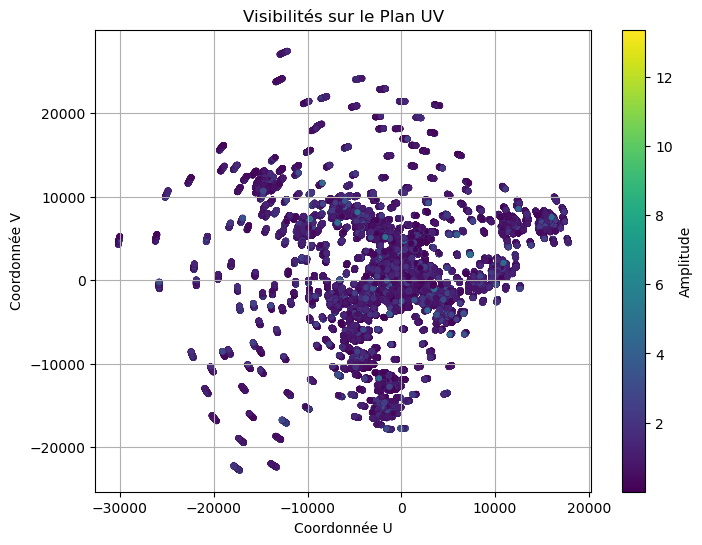

In [1]:
from script.plot_vis import plot_visibilities

plot_visibilities("../example/GLEAM_small_visibilities_corrupted.csv")

Amplitude totale des visibilités : 4687938.434363295


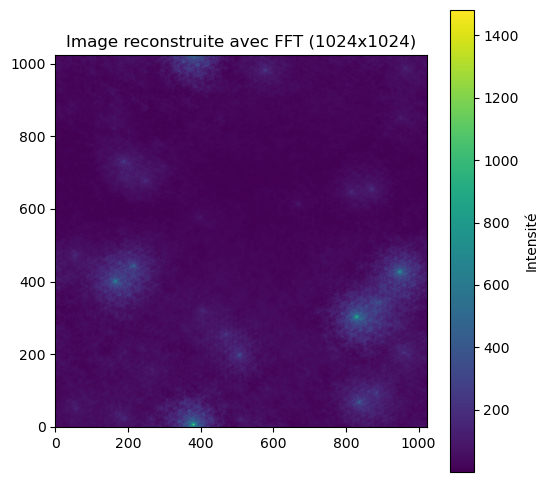

Max vis: 13.367794202018839
Sum vis: 4687938.434363295
Max grid: 35349.59
Amplitude maximale : 1481.6018537976045


In [3]:
from script.fft_reconstruction import *

reconstruct_image("../example/GLEAM_small_visibilities_corrupted.csv", 1024)

*The figure illustrate the reconstructed image from small gleam dataset with simple **FFT** reconstruction. The process is very fast but the quality of the reconstruction very poor*

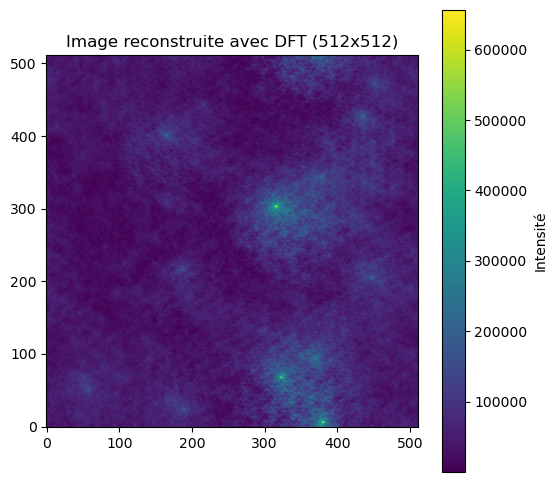

In [7]:
from script.dft_reconstruction import *

reconstruct_image_dft("../example/GLEAM_small_visibilities_corrupted.csv", 512)

*The figure illustrate the reconstructed image from small gleam dataset with simple **DFT** reconstruction. The process is super long but the quality of the reconstruction better*

> **Nota Bene**: The grid size (`grid_size`) directly affects the quality of the reconstruction:
>
> - **Small grid**: Lower resolution, sources appear more concentrated and blurry. Fewer artifacts, but fewer details.
> - **Large grid**: Higher resolution, more details. However, if the visibilities don't sufficiently cover the UV plane, artifacts may appear.
>
> So, it's all about finding the right balance

In this tutorial we will:
- employ the `std_degridder()` implemented into the **PREESM** framework to generate custom visibilities
- reconstruct image to check the consistency of our custom visibilities with:
    - a simple fft (vanilla python implem).
    - a dataflow cufft implem.
    - a DFT-based radio-interferometric imaging pipeline also implemented into **PREESM**.
    

In [18]:
import base64
from IPython.display import Image, display
import matplotlib.pyplot as plt

def mm(graph):
  graphbytes = graph.encode("ascii")
  base64_bytes = base64.b64encode(graphbytes)
  base64_string = base64_bytes.decode("ascii")
  display(
    Image(
      url="https://mermaid.ink/img/"
      + base64_string
    )
  )

mm("""
graph LR;
    A["True Sky I(l,m)"] --> B["Degridding"];
    D["Interferometer Config (kernel + uvw coord)"] --> B["Degridding"];
    B --> C["Visibility V(u,v,w)"];
""")



## `std_degridding()` principle
Degridding is a key stage in the imaging process, where the values of a regular grid are interpolated to irregular points (the visibilities).

#### 🔎 The std_degridding consist in:
- Take an `input_grid` containing the transformed data.
- Extract (interpolate) the values at specific positions defined by the `corrected_vis_uvw_coords`.
- Apply a correction via an interpolation `kernel`.
- Store the result in `output_visibilities`.


#### 🧱 Function parameters:

```c
void std_degridding(
 int GRID_SIZE, // Grid size (GRID_SIZE x GRID_SIZE)
 int NUM_VISIBILITIES, // Total number of visibilities to process
 int OVERSAMPLING_FACTOR, // Oversampling factor for fine interpolation
 PRECISION2* kernels, // Array containing kernel samples
 int2* kernel_supports,             // Table containing the kernel supports
 PRECISION2* input_grid, // Table containing the input grid
 PRECISION3* corrected_vis_uvw_coords, // Table containing the corrected UVW coordinates
 int* num_corrected_visibilities, // Number of corrected visibilities to process
 Config* config, // Global configuration (UV and W scales)
 PRECISION2* output_visibilities // Output table containing the extracted visibilities
)
```

#### Complexity O(n):

Degridding can be time-consuming depending on certain parameters, which are worth revealing.
The complexity of this calculation is dominated by three nested loops:

$O(n_v . n_{\mathcal{D}}²)$, where:

- $n_v$ is the number of corrected visibilities (or `*num_corrected_visibilities`),
- $n_{\mathcal{D}}$ is a measure of the size of the kernel (or more precisely half the size of the kernel support on each axis).

This means that the complexity of the calculation increases quadratically with the size of the kernel support and linearly with the number of corrected visibilities.


---
## Steps:

1. Générer une image **true sky** avec pour paramètres : `GRID_SIZE`, `NUM_SOURCE` → `true_sky.csv`.
2. Générer les noyaux de convolution avec pour paramètres : `NUM_KERNEL`, `OVERSAMPLING_FACTOR` → `kernel.csv`. 
3. Exécuter `./STD_DEGRID` → `vis.csv`.
4. Afficher les visibilités générées sur le plan $uv$.
5. Reconstruire l'image : 
    - **Avec CUFFT inverse**
    - **Avec une fft python simple**
    - **Avec GIP DFT**  (en cours)
        1. Générer la PSF depuis les visibilités générées.  
        2. Exécuter `./SEP_Pipeline` → `reconstructed_image.csv`. 
    
6. Analyser la qualité

### 1. Run the custom script to generate a custom `*.fits` converted as `*.csv`

Fichier FITS généré : code/radioastro.fits
Max pos in true sky: (13, 9)


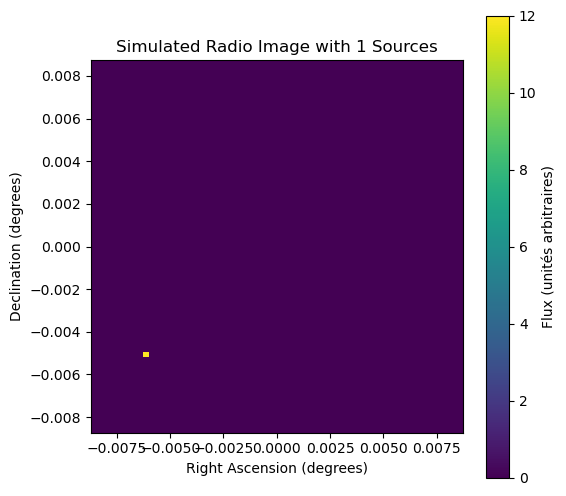

Fichier sauvegarder dans : code/image.csv


In [1]:
from script.fits_to_csv import generate_fits, generate_csv


GRID_SIZE = 64
NUM_SOURCES = 1
SIGMA=0.1 # Largeur de la gaussienne (en pixels)

generate_fits(GRID_SIZE, NUM_SOURCES, SIGMA, "code/radioastro.fits")
generate_csv("code/radioastro.fits","code/image.csv")



### 2. Build kernels

[dire un truc super]

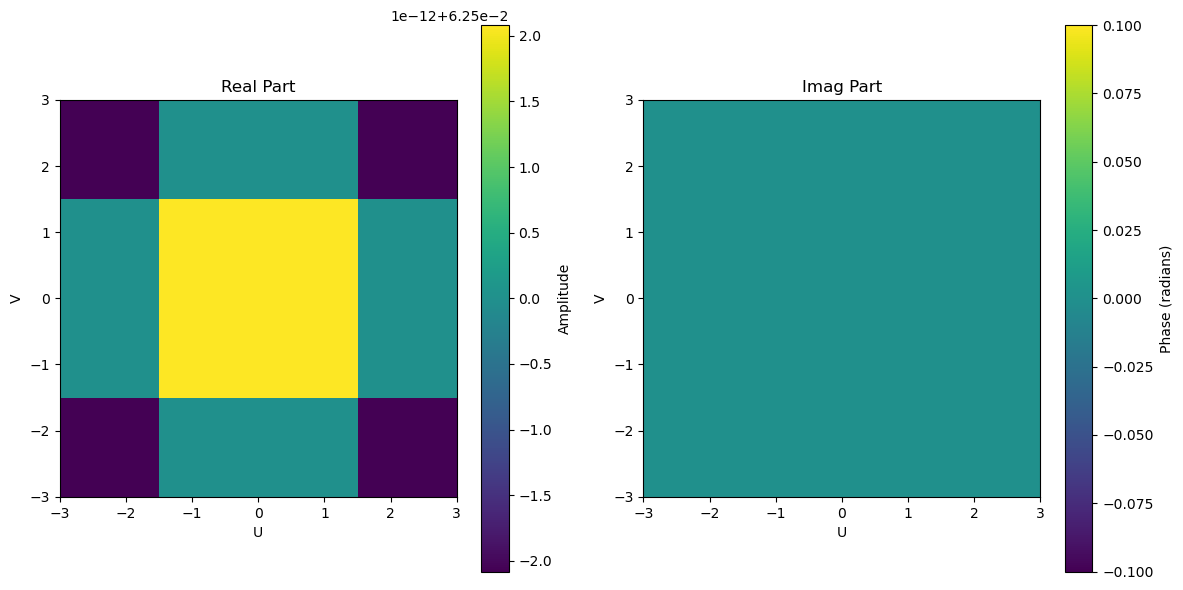

✅ Kernel générés et exportés dans code/config/kernel_imag.csv,code/config/kernel_real.csv et code/config/kernel_support.csv


In [27]:
from script.kernel import *

grid_size = 64
num_kernels = 17
oversampling_factor = 16
kernel_support = 6
baseline_max = 43000 #43 km
beta = 2.0  # Paramètre de la fenêtre Kaiser-Bessel
kernel_width = 4.0  # Largeur du noyau
SPEED_OF_LIGHT = 3e8  # Vitesse de la lumière en m/s
frequency_hz = SPEED_OF_LIGHT/0.21
filepath = "code/config/"

generate_kernel(grid_size, num_kernels, oversampling_factor, kernel_support, beta, kernel_width, baseline_max, frequency_hz, filepath)


#### Step 4: run the dataflow executable

In [3]:
import os
import subprocess

# Chemin vers le dossier dataflow
dataflow_directory = "code"

# Vérifie si on est déjà dans le bon dossier
current_directory = os.getcwd()
if not current_directory.endswith(dataflow_directory):
    print(f"Le répertoire actuel est {current_directory}. Changement vers {dataflow_directory}...")
    os.chdir(dataflow_directory)
else:
    print(f"On est déjà dans le répertoire {dataflow_directory}.")

EXECUTABLE = "./STD_DEGRID"

print(f"Lancement : {EXECUTABLE}")
result = subprocess.run(EXECUTABLE, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print(f"Erreur :\n{result.stderr}")

#Retourner d'où on vient    
os.chdir("..")
print(os.getcwd())



Le répertoire actuel est /home/orenaud/Documents/GITHUB/VIS/vis-generator/dataflow_simulator. Changement vers code...
Lancement : ./STD_DEGRID
max_w: 3809.523810
w_scale: 0.067200
uv_scale: 0.017453
UPDATE >>> Image loaded from image.csv, 4096 elements 

Points de coordonnées de visibilités générés : 5000 (attendus : 5000)

✅ PNG sauvegardé : input_heatmap.png
UPDATE >>> Shifting grid data for FFT...

Image saved to CSV: input_grid.csv
UPDATE >>> Performing FFT...

Image saved to CSV: uv_grid.csv
UPDATE >>> Shifting grid data for FFT...

Image saved to CSV: uv_grid_shift.csv
Degridding visibilities using FFT degridder
UPDATE >>> Image degridded successfully
UPDATE >>> write csv to vis.csv

FINISHED GRIDDING
UPDATE >>> Performing iFFT...

Image saved to CSV: reconstructed.csv
UPDATE >>> Shifting grid data for FFT...

Image saved to CSV: reconstructed_shift.csv
✅ PNG sauvegardé : reconstructed_heatmap.png

/home/orenaud/Documents/GITHUB/VIS/vis-generator/dataflow_simulator


#### Step 5: Visualize the generated visibilities

Min u : -3440.000244, Max u : 3520.0
Min v : -3440.000244, Max v : 3513.053955
Min réel : -0.287341, Max réel : 0.25149
Min imaginaire : -0.220311, Max imaginaire : 0.470719
Maximum d'amplitude : 0.5015728359520678


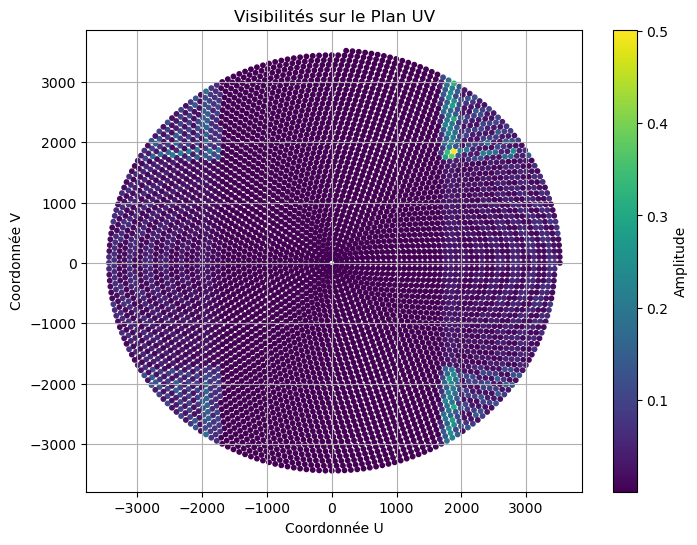

In [4]:
from script.plot_vis import plot_visibilities

plot_visibilities("code/vis.csv")

### Step 5: Reconstruction image

#### Version fft python simple
Une version python de reconstruction via une simple fft est fournie dans le projet. Elle permet un controle rapide de la qualité des visibilité mais le code est claqué au sol. Toutefois multiplié les méthode de control permet de s'assurer de la cohérence du truc.

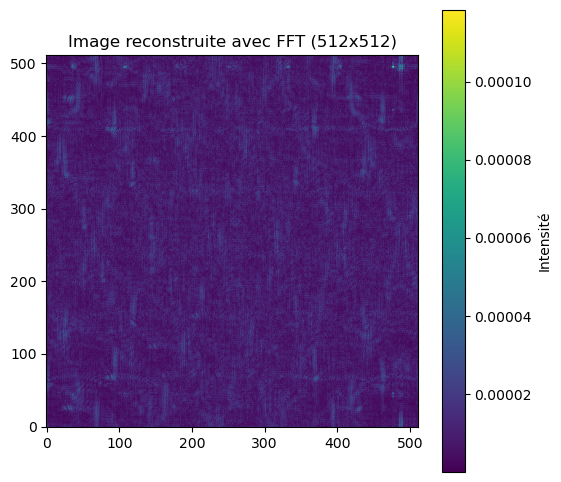

Max vis: 0.5015728359520679
Sum vis: 91.17802060811111
Max grid: 0.50157285
Amplitude maximale : 0.00011841791379093424


In [4]:
from script.fft_reconstruction import *

grid_size = 512

reconstruct_image("code/vis.csv", grid_size)

📄 ***Analysis**: erreur de normalisation d'où l'écart d'intensité (attendu 12) à corriger, le pixel est étalé due au noyaux de convolution grossier --> affiner le noyaux permet une interpolation plus fin au cout du temps de processus*

#### Version cufft c
A la suite du degridder standard j'ai ajouter les étape de pipeline de gridding standard et de reconstruction via l'inverse CUFFT pour analyser directement la cohérence des visibilité sous une configuration identique à ce qui nous a servi pour le degridding.

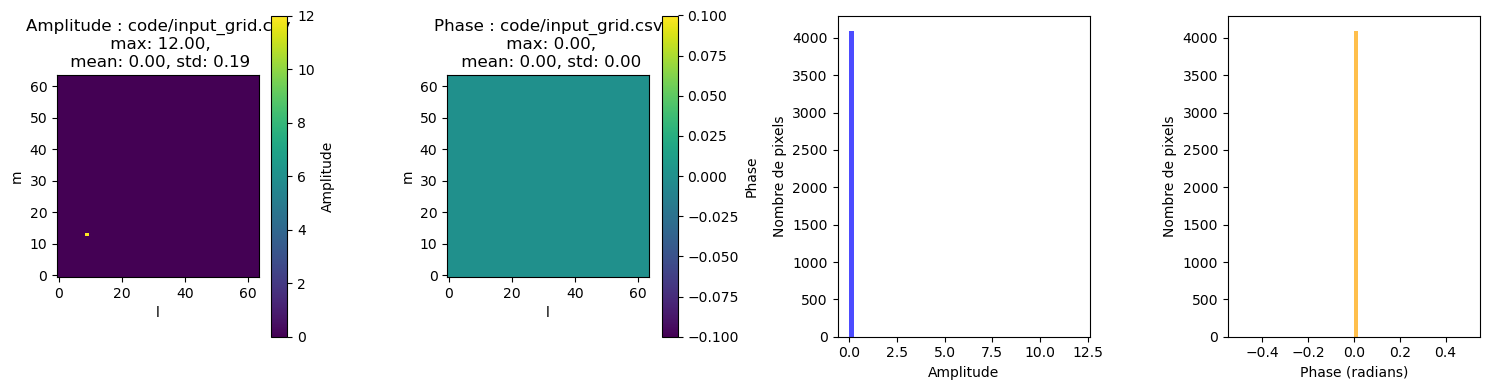

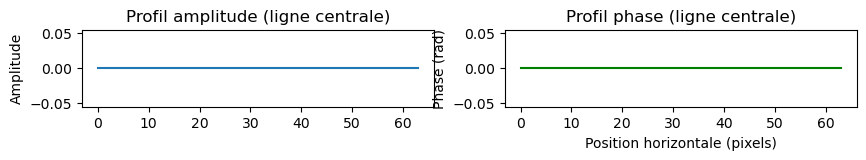

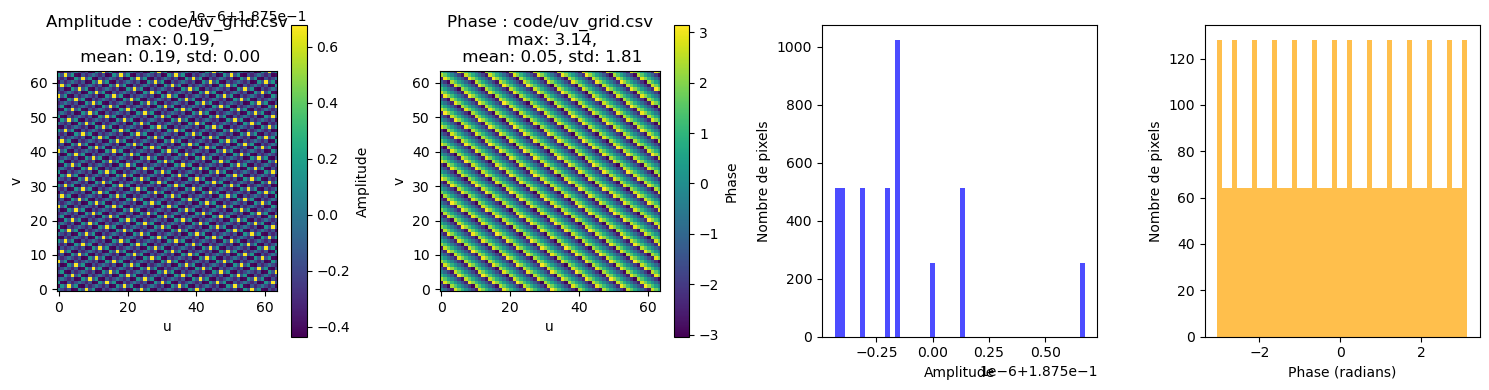

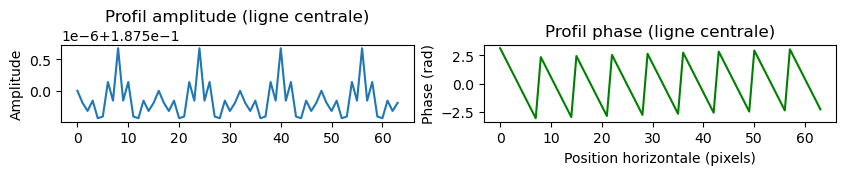

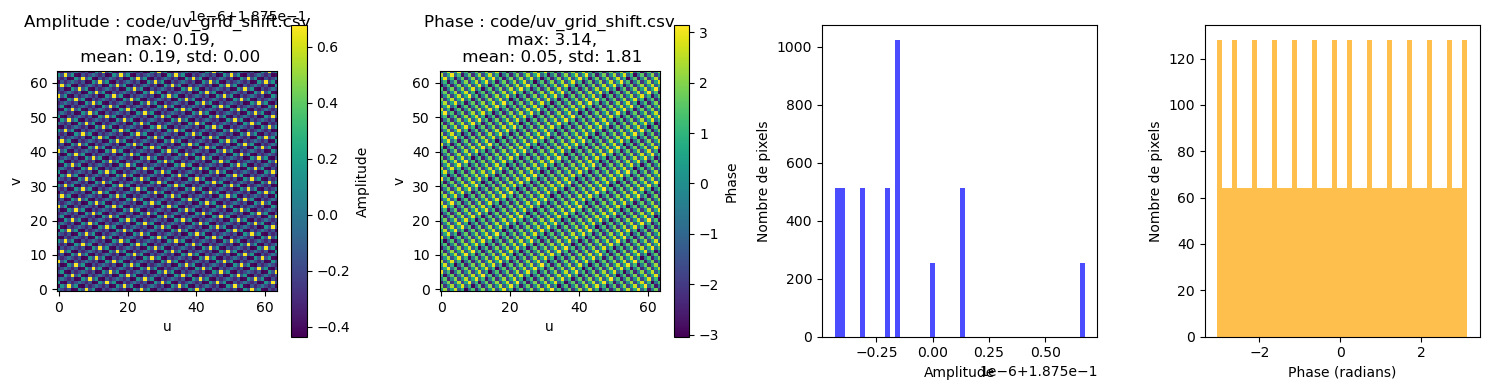

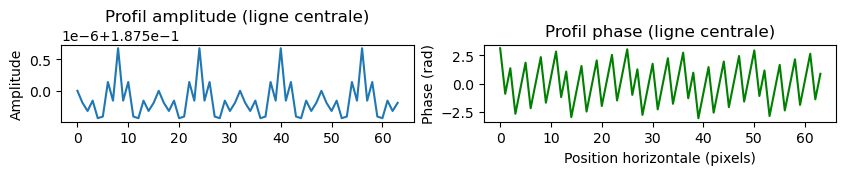

In [6]:
from script.csv_to_image import *

grid_size = 64

csv_file = 'code/input_grid.csv'

load_image_from_csv(csv_file, grid_size,"lm")

csv_file = 'code/uv_grid.csv'

load_image_from_csv(csv_file, grid_size,"uv")

csv_file = 'code/uv_grid_shift.csv'

load_image_from_csv(csv_file, grid_size,"uv")


📄 ***Analysis**: Les étapes préliminaires sont : lecture de la grille → (1) `fftshift` sur le plan $l,m$ → (2) CUFFT → (3) `fftshift` sur le plan $u,v$.  
On part d’une source ponctuelle (un pixel d’intensité 12).*

*(1) **But attendu** : centrer la source dans le plan image pour une transformée de Fourier correcte (sinon, le pic apparaît en coin).  
**Amplitude** : inchangée, avec un maximum à 12, répartie sur un seul pixel → conforme.  
**Phase** : nulle partout (max = 0, mean = 0), ce qui est attendu pour une source purement réelle sans composante imaginaire → conforme.*

*(2) **But attendu** : la transformée de Fourier d’un point centré est une constante uniforme, donc on attend une amplitude constante sur tout le plan UV et une phase également constante.  
**Amplitude** : max = 0.19 ≈ 12 / 64 → conforme à l’effet attendu d’une FFT sur une source centrée (l’énergie est répartie sur toute la grille).  
**Phase** : non nulle (max ≈ π, std ≈ 1.81), ce qui suggère une variation non souhaitée — possiblement due à des imprécisions numériques (float32), un léger décentrage de la source, une normalisation incorrecte ou des spécificités de l’implémentation CUFFT.*

*(3) **But attendu** : recentrer l’origine des fréquences pour une lecture plus intuitive (le zéro spatial au centre du plan UV).  
**Amplitude** : reste inchangée → conforme.  
**Phase** : le profil spatial change (ce qui est normal), mais les statistiques globales (mean, std) restent proches → conforme.*

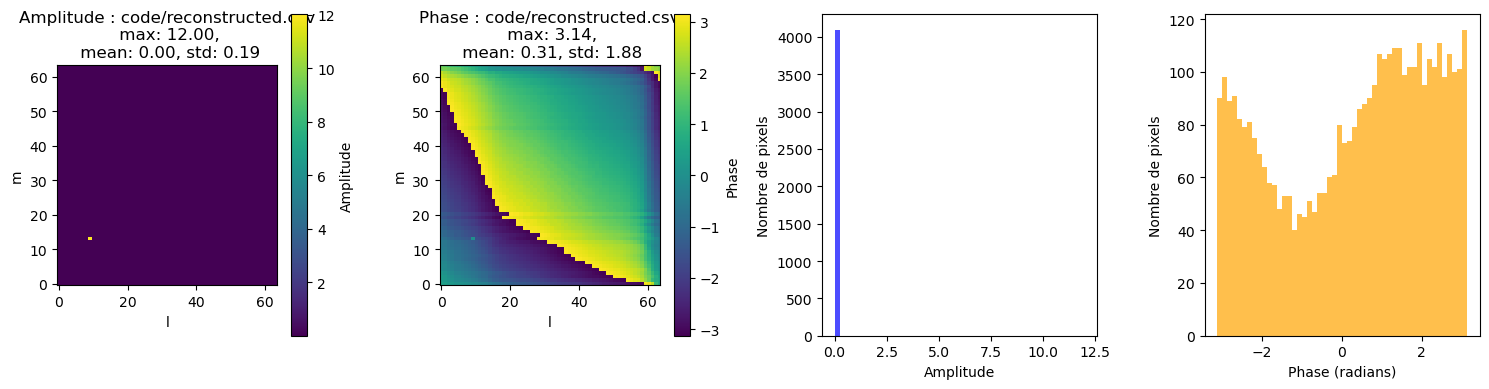

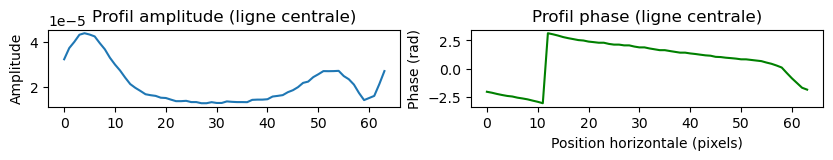

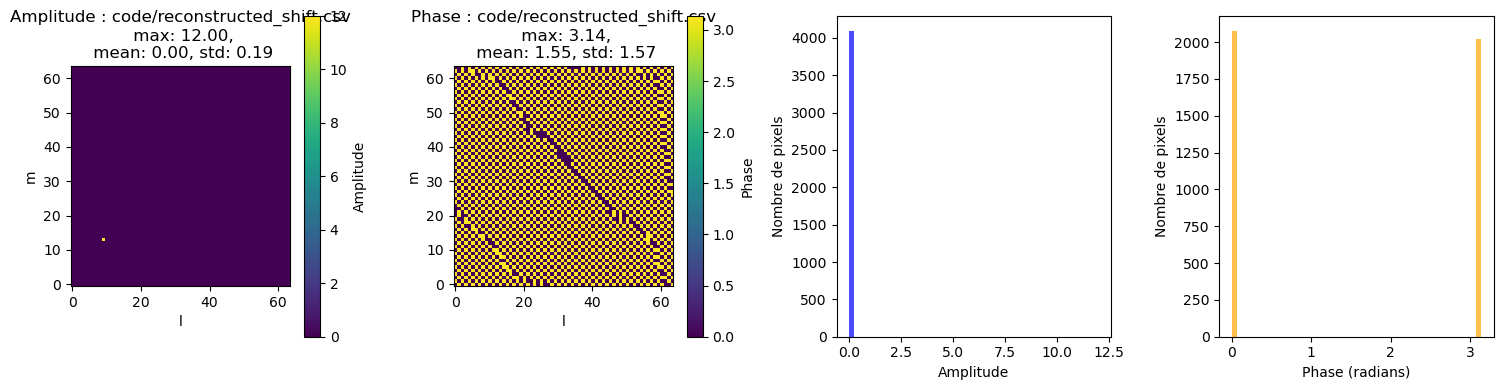

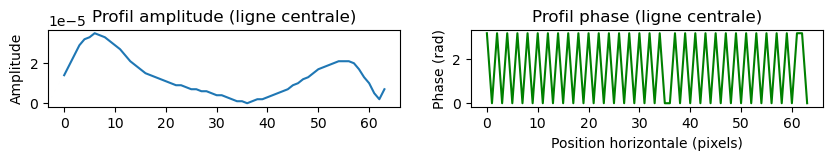

In [7]:
from script.csv_to_image import *

grid_size = 64

csv_file = 'code/reconstructed.csv'

load_image_from_csv(csv_file, grid_size,"lm")

csv_file = 'code/reconstructed_shift.csv'

load_image_from_csv(csv_file, grid_size,"lm")


📄 ***Analysis**: Les étapes suivantes sont : (4) degridding → (5) gridding → (6) CUFFT inverse → (7) `fftshift`.  
On poursuit avec une source ponctuelle reconstruite à partir du plan UV.*

*(6) **But attendu** : la transformée de Fourier inverse d’un plan UV uniforme (amplitude constante, phase constante) devrait redonner une source centrée dans le plan image.  
**Amplitude** : max = 12, mean ≈ 0.01, std ≈ 0.19 → compatible avec une concentration de l’énergie sur un seul pixel.  
**Phase** : max ≈ π, mean ≈ 0.06, std ≈ 1.82 → la phase n’est pas constante comme attendu ; cela pourrait être dû à des imprécisions numériques accumulées, une interpolation imparfaite au degridding/gridding, ou une perte de symétrie complexe. Les profils d’amplitude et de phase sont très différents de l’état initial, ce qui peut refléter un artefact d’implémentation ou une perte d’information.*

*(7) **But attendu** : recentrer le pic d’intensité au centre du plan image pour vérification visuelle.  
**Amplitude** : max = 12, mean ≈ 0, std ≈ 0.19 → conforme, pic conservé.  
**Phase** : max ≈ π, mean ≈ 1.92, std ≈ 1.53 → la phase présente une structure complexe, probablement liée aux perturbations accumulées précédemment.*

In [8]:
import numpy as np

def calculate_error(original_file, reconstructed_file):
    # Charger les données depuis les fichiers CSV
    original_data = np.loadtxt(original_file, delimiter=',')
    reconstructed_data = np.loadtxt(reconstructed_file, delimiter=',')

    # Calculer l'erreur quadratique moyenne (MSE)
    mse = np.mean((original_data - reconstructed_data) ** 2)

    # Calculer l'erreur absolue moyenne (MAE)
    mae = np.mean(np.abs(original_data - reconstructed_data))

    return mse, mae

# Liste des paires de fichiers à comparer
comparisons = [
    ("code/input_grid.csv", "code/reconstructed.csv", "Sans fftshift"),
    ("code/input_grid.csv", "code/reconstructed_shift.csv", "Avec fftshift"),
]

# Calcul et affichage des erreurs
for original_file, reconstructed_file, description in comparisons:
    mse, mae = calculate_error(original_file, reconstructed_file)
    print(f"\n--- Comparaison: {description} ---")
    print(f"Erreur Quadratique Moyenne (MSE): {mse:.6f}")
    print(f"Erreur Absolue Moyenne (MAE): {mae:.6f}")



--- Comparaison: Sans fftshift ---
Erreur Quadratique Moyenne (MSE): 0.000000
Erreur Absolue Moyenne (MAE): 0.000023

--- Comparaison: Avec fftshift ---
Erreur Quadratique Moyenne (MSE): 0.000000
Erreur Absolue Moyenne (MAE): 0.000012


📄 ***Analysis**: Les erreurs sont faible on est content. Le fftshift aide bien à recentrer les composantes fréquentielles pour la reconstruction, et améliore la fidélité. C’est cohérent avec ce qu’on attend en théorie : sans recentrage, la TF inverse "remet les infos au mauvais endroit", d'où un petit écart.*

#### version Generic_Imaging_Pipeline(DFT) -- en cours de dev

The DFT pipeline takes the following as input:
- Visibilities (done ✅)
- Kernels (done ✅)
- PSF (not yet)

###### PSF
The PSF tells us how a point source is blurred by the system. 
To calculate the Point Spread Function (PSF):
- Set all visibilities to 1: We simulate an ideal case where the signal is perfect (no noise) 📡 ➡️ 1.
- Apply a Fast Fourier Transform (FFT): The FFT transforms the data from frequency to spatial domain, showing how the system would respond to a point source 🌀 ➡️ 🌟.

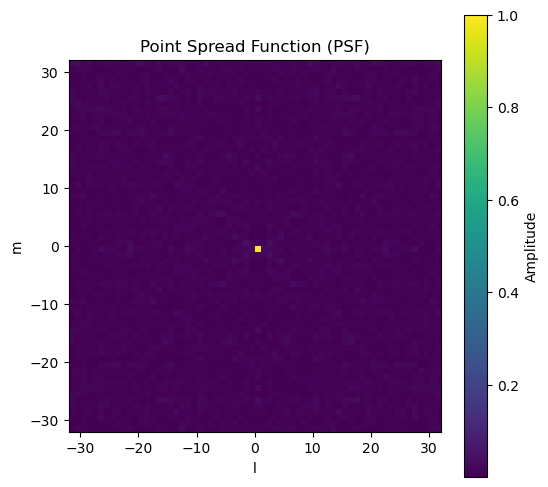

✅ PSF générée et exportée dans code_dft/data/input/psf.csv


In [9]:
from script.psf import generate_psf
GRID_SIZE = 64
generate_psf(GRID_SIZE,"code/vis.csv","code_dft/data/input/psf.csv")

In [10]:
import os
import subprocess

# Chemin vers le dossier du pipeline
dataflow_directory = "code_dft"

# Vérifie si on est déjà dans le bon dossier
current_directory = os.getcwd()
if not current_directory.endswith(dataflow_directory):
    print(f"Le répertoire actuel est {current_directory}. Changement vers {dataflow_directory}...")
    os.chdir(dataflow_directory)
else:
    print(f"On est déjà dans le répertoire {dataflow_directory}.")

EXECUTABLE = "./SEP_Pipeline"

print(f"Lancement : {EXECUTABLE}")
result = subprocess.run([EXECUTABLE, "5000", "64", "200"], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print(f"Erreur :\n{result.stderr}")
    
os.chdir("..")
print(os.getcwd())

Le répertoire actuel est /home/orenaud/Documents/GITHUB/VIS/vis-generator/dataflow_simulator. Changement vers code_dft...
Lancement : ./SEP_Pipeline
UPDATE >>> PSF read from file with max value to scale grid = 1.000000...

UPDATE >>> PSF read from file with max value to scale grid = 1.000000...

UPDATE >>> PSF read from file with max value to scale grid = 1.000000...

UPDATE >>> PSF read from file with max value to scale grid = 1.000000...

UPDATE >>> PSF read from file with max value to scale grid = 1.000000...

UPDATE >>> Loading degridding kernel support file from ../code/config/kernel_support.csv...

UPDATE >>> Total number of samples needed to store degridding kernels is 39168...

kernel_supports MD5 	: 2DE3D90E32F3E37804F97633145C087E
UPDATE >>> Loading kernel files file from ../code/config/kernel_real.csv real and ../code/config/kernel_imag.csv imaginary...

UPDATE >>> Loading kernel support file from ../code/config/kernel_support.csv...

UPDATE >>> Total number of samples neede

The Generic_Imaging_Pipeline(DFT) generates csv all along the iterative process. Here we convert the produced **\*.csv** into **\*.fits** and display produced image by type.

✅ Converted all CSV files from code_dft/data/output/tune/ to code_dft/data/fits/


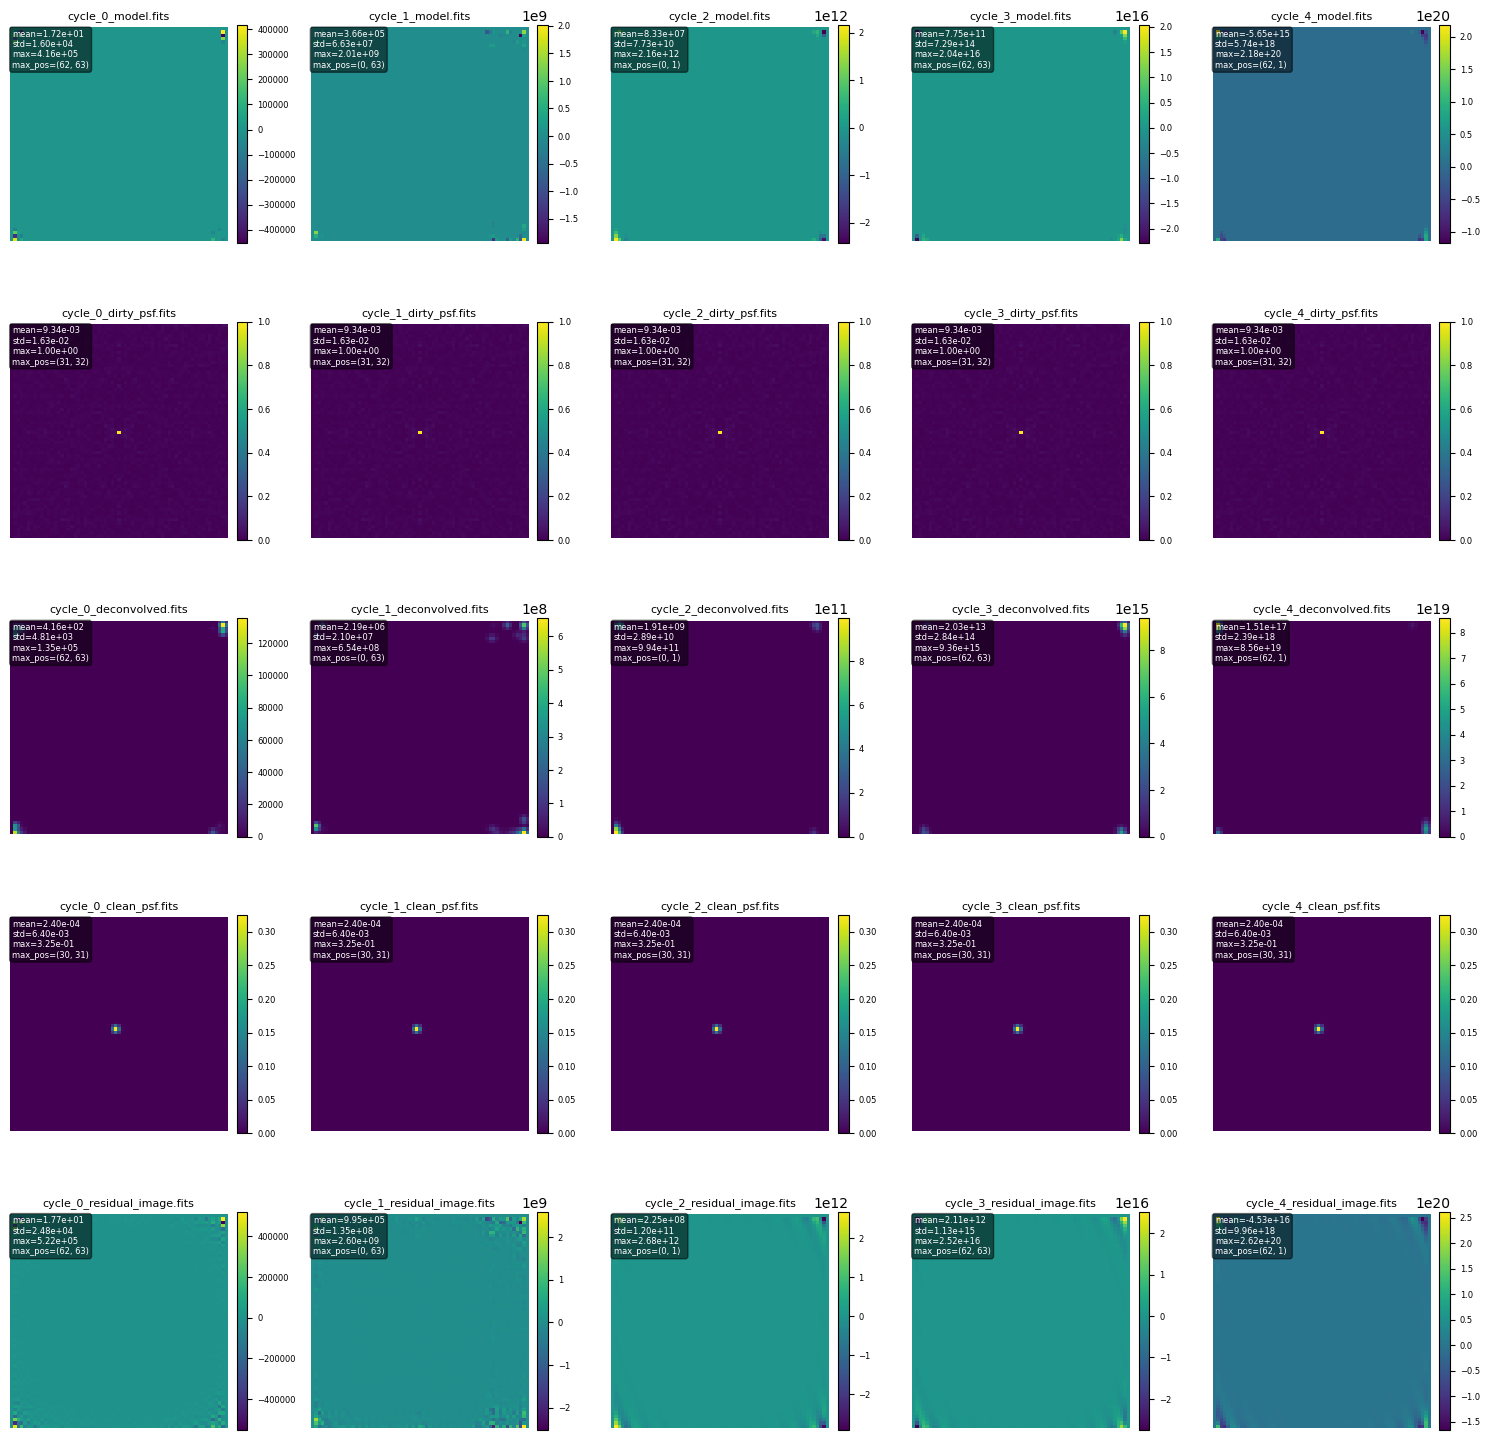

In [11]:
from script.csv_to_fits import *

input_directory = "code_dft/data/output/tune/"
output_directory = "code_dft/data/fits/"
delimiter = ","
convert_all_csv_in_directory(input_directory, output_directory, delimiter)

from script.plot_im import *

base_dir = 'code_dft/data/fits'
types = ['model', 'dirty_psf', 'deconvolved', 'clean_psf', 'residual_image']

display_images_by_type(base_dir, types)

📄 ***Analysis**: L'algorithme iteratif ne converge pas mais plutot oscille entre un resultat proche de l'image true sky et un truc pourri. On a toutefois un souci d'amplitude --> à investiguer.*